# Анализ числовых, бинарных и категориальных признаков

## 0. Импорты и загрузка данных

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")  # запускать из корня репозитория

from src.correlation_analysis import (
    encode_for_correlation,
    location_id_dispersion,
    location_match_rate,
    propensity_table,
)
from src.feature_loading import load_item_features, load_train_features

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "dataset"

In [2]:
train = load_train_features(DATA_DIR)   # 497 673 пар (запрос, выбранное объявление)
items = load_item_features(DATA_DIR)    # 189 212 объявлений корпуса — "популяция"

print(f"train: {len(train):,} строк")
print(f"benchmark_items: {len(items):,} строк")
train.dtypes

train: 497,673 строк
benchmark_items: 189,212 строк


search_location_id             int64
search_is_delivery_search      int32
search_category                int64
item_location_id               int64
item_latitude                float64
item_longitude               float64
item_category_id               int64
item_microcat_id               int64
item_price                   float64
item_rating                  float64
item_rating_reviews_count    float64
item_is_phone_hidden            bool
item_is_message_forbidden       bool
dtype: object

In [3]:
print("Доли пропусков в train:")
train.isna().mean().sort_values(ascending=False)

Доли пропусков в train:


item_rating                  0.056728
item_rating_reviews_count    0.038602
item_latitude                0.000008
item_longitude               0.000008
search_location_id           0.000000
search_is_delivery_search    0.000000
search_category              0.000000
item_location_id             0.000000
item_category_id             0.000000
item_microcat_id             0.000000
item_price                   0.000000
item_is_phone_hidden         0.000000
item_is_message_forbidden    0.000000
dtype: float64

## 1. Локация

У запроса есть только `search_location_id` (координат нет), у объявления —
`item_location_id` и координаты. Сначала проверим, что `location_id` вообще
что-то значит географически: если объявления с одним и тем же
`item_location_id` разбросаны по карте — это скорее большой регион, и точное
совпадение id было бы слишком грубым фильтром; если разброс маленький —
можно использовать точное совпадение id как содержательный сигнал близости.

In [4]:
dispersion = location_id_dispersion(items)
print(f"Локаций с ≥5 объявлениями: {len(dispersion):,}")
dispersion[["lat_std", "lon_std", "n_items"]].describe()

Локаций с ≥5 объявлениями: 1,514


,lat_std,lon_std,n_items
count,1514.000000,1514.000000,1514.000000
mean,0.111276,0.123774,123.182959
std,0.749500,0.770753,671.536942
min,0.000000,0.000000,5.000000
25%,0.004544,0.007988,8.000000
50%,0.010134,0.017068,17.000000
75%,0.021842,0.038508,53.750000
max,14.126864,15.764631,19542.000000


Медианное стандартное отклонение координат внутри одного `location_id` —
около 0.01° (~1 км), то есть для подавляющего большинства локаций это
действительно небольшой район, а не регион целиком (у отдельных `location_id`
разброс намного больше — вероятно, немногочисленные объявления с ошибками в
координатах или id, покрывающие широкую область). Значит точное совпадение
`search_location_id == item_location_id` — осмысленный, не слишком грубый
сигнал близости.

In [5]:
overall_match = location_match_rate(train)
print("Доля пар (запрос, выбранное объявление) с совпадающей локацией:")
print(overall_match)

Доля пар (запрос, выбранное объявление) с совпадающей локацией:
overall    0.83102
dtype: float64


In [6]:
match_by_category = location_match_rate(train, group_by="search_category")
print("Совпадение локации по категориям запроса (n мало для 10/81, см. предупреждение ниже):")
print(match_by_category)
print()
print("Число запросов на категорию:", train["search_category"].value_counts().to_dict())

Совпадение локации по категориям запроса (n мало для 10/81, см. предупреждение ниже):
search_category
114    0.831029
0      0.735294
10     0.500000
81     0.500000
dtype: float64

Число запросов на категорию: {114: 497635, 0: 34, 81: 2, 10: 2}


**Вывод.** ~83% выбранных объявлений находятся ровно в той же локации, что и запрос.
Это значимый сигнал, поэтому здесь оправдан **мягкий** сигнал (бонус за совпадение или близость в RRF).

## 2. Категория и микрокатегория

### 2.1. Согласованность `search_category` и `item_category_id`

Прежде чем полагаться на `search_category` как на жёсткий фильтр
кандидатогенерации (`candidate_generation.ipynb`), стоит проверить, что оно вообще
совместимо с `item_category_id` выбранного объявления.

In [ ]:
category_match_rate = (train["search_category"] == train["item_category_id"]).mean()
print(f"Доля строк трейна, где search_category == item_category_id: {category_match_rate:.4%}")
print()
print("Уникальные значения search_category в train:", sorted(train["search_category"].unique()))
print("Есть ли объявления с item_category_id == 0:", (items["item_category_id"] == 0).any())

**Вывод.** 99.99% строк трейна — точное совпадение, жёсткий фильтр по
категории оправдан. Но `item_category_id` никогда не равен 0, а
`search_category == 0` ("категория не выбрана") встречается в некоторых
запросах — для них фильтр нельзя применять буквально (см.
`CandidateGenerator._category_mask` в `candidate_generation.ipynb`: `search_category
== 0` отключает фильтр вместо того, чтобы отсечь все объявления).

### 2.2. Микрокатегория

`item_category_id` (уже используется как жёсткий фильтр) — грубое деление,
всего 46 значений в корпусе, из них 99% объявлений — категория 114
("Услуги"). `item_microcat_id` — куда более дробное деление внутри
категории. Посмотрим, насколько оно тоньше.

In [7]:
print("Категорий:", items["item_category_id"].nunique())
print("Микрокатегорий:", items["item_microcat_id"].nunique())
print()
microcats_per_category = items.groupby("item_category_id")["item_microcat_id"].nunique().sort_values(ascending=False)
print("Микрокатегорий на категорию (топ-10):")
microcats_per_category.head(10)

Категорий: 47
Микрокатегорий: 752

Микрокатегорий на категорию (топ-10):


item_category_id
114    202
19     118
10      48
40      44
20      34
39      32
27      22
36      22
111     20
24      16
Name: item_microcat_id, dtype: int64

Внутри одной категории может быть несколько десятков микрокатегорий — то
есть `item_category_id` сам по себе слабо разделяет объявления внутри
категории 114 (где и так 99% корпуса). Судя по абляции в `candidate_generation.ipynb`
(coverage параметров даёт малый прирост поверх жёсткого фильтра по
категории), микрокатегория — кандидат на более точный **мягкий** сигнал: у
запроса нет прямого поля "microcat", но `search_infm_params_text`
(например, "Вид услуги Красота, здоровье") по сути и есть текстовое описание
нужной микрокатегории. В `candidate_generation.ipynb` это реализовано как
`MicrocatMatchIndex` — центроид эмбеддингов объявлений каждой
микрокатегории и косинусная близость к эмбеддингу запроса.

## 3. Бинарные флаги

`search_is_delivery_search` (запрос), `item_is_phone_hidden`,
`item_is_message_forbidden` (объявление). Сравниваем долю `True` среди
выбранных объявлений против всего корпуса — устойчивое отличие означает
предпочтение.

In [8]:
print("Доля запросов с флагом доставки:", train["search_is_delivery_search"].mean())
print("(почти всегда 0 — признак редкий и малоинформативен сам по себе)")

Доля запросов с флагом доставки: 2.4112218263799723e-05
(почти всегда 0 — признак редкий и малоинформативен сам по себе)


In [9]:
flag_propensity = propensity_table(
    train, items,
    binary_columns=["item_is_phone_hidden", "item_is_message_forbidden"],
)
flag_propensity

,feature,statistic,chosen,population,delta
0,item_is_phone_hidden,rate,0.121423,0.155947,-0.034524
1,item_is_message_forbidden,rate,0.020905,0.026600,-0.005694


**Вывод.** Оба флага у выбранных объявлений встречаются реже, чем в корпусе
в среднем: скрытый телефон — на 3.5 п.п. реже (12.1% против 15.6%),
запрещённые сообщения — на 0.6 п.п. реже. Эффект небольшой, но
систематический и в одну сторону — пользователи слегка предпочитают
объявления с открытым контактом. Как жёсткий фильтр не годится (это
отсекло бы совершенно нормальные объявления), но как маленький штраф на
этапе переранжирования — оправдан.

## 4. Числовые признаки объявления: цена, рейтинг, число отзывов

`item_price` содержит выбросы (вплоть до `-1` и значений за 10^11 — похоже
на плейсхолдеры/ошибки ввода), поэтому сравниваем по медиане и смотрим на
распределение в лог-шкале, а не на сырое среднее.

In [10]:
numeric_propensity = propensity_table(
    train, items,
    numeric_columns=["item_price", "item_rating", "item_rating_reviews_count"],
)
numeric_propensity

,feature,statistic,chosen,population,delta
0,item_price,median,1000.0,1000.0,0.0
1,item_rating,median,5.0,5.0,0.0
2,item_rating_reviews_count,median,25.0,18.0,7.0


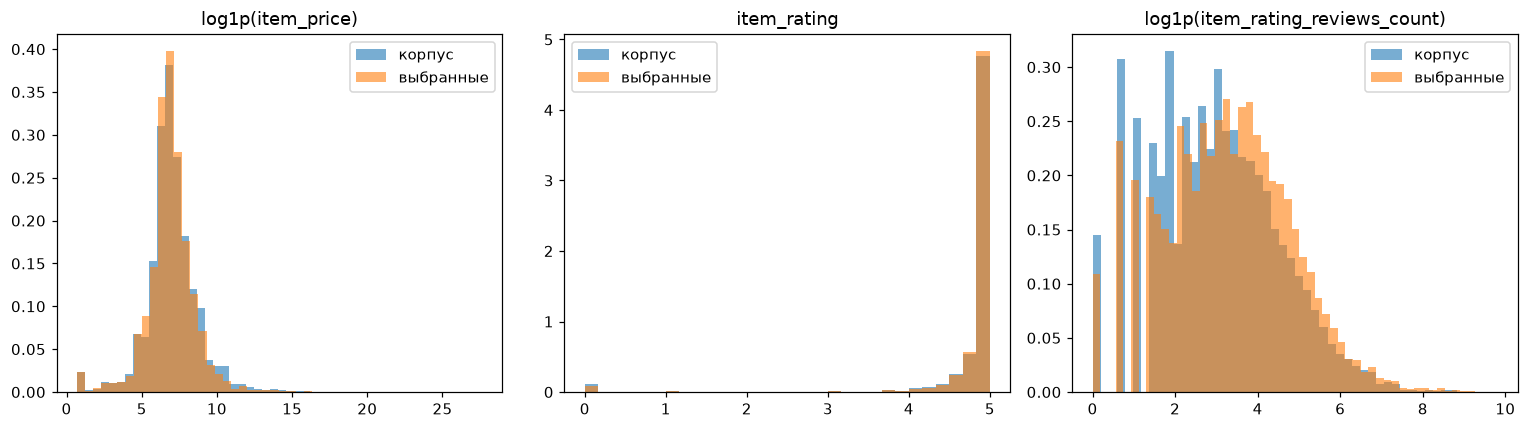

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

price = items["item_price"].where(items["item_price"] > 0)
axes[0].hist(np.log1p(price.dropna()), bins=50, alpha=0.6, label="корпус", density=True)
axes[0].hist(
    np.log1p(train["item_price"].where(train["item_price"] > 0).dropna()),
    bins=50, alpha=0.6, label="выбранные", density=True,
)
axes[0].set_title("log1p(item_price)")
axes[0].legend()

axes[1].hist(items["item_rating"].dropna(), bins=30, alpha=0.6, label="корпус", density=True)
axes[1].hist(train["item_rating"].dropna(), bins=30, alpha=0.6, label="выбранные", density=True)
axes[1].set_title("item_rating")
axes[1].legend()

axes[2].hist(np.log1p(items["item_rating_reviews_count"].dropna()), bins=50, alpha=0.6, label="корпус", density=True)
axes[2].hist(np.log1p(train["item_rating_reviews_count"].dropna()), bins=50, alpha=0.6, label="выбранные", density=True)
axes[2].set_title("log1p(item_rating_reviews_count)")
axes[2].legend()

fig.tight_layout()
plt.show()

**Вывод.** Цена и рейтинг у выбранных объявлений распределены почти так же,
как в корпусе в среднем (медианы совпадают, рейтинг у обоих сильно прижат к
5.0 — типичный эффект отзывов на маркетплейсах). А вот **число отзывов**
у выбранных объявлений заметно выше (медиана 25 против 18 в корпусе,
на гистограмме видно смещение вправо) — похоже на реальный сигнал
популярности/доверия, полезный как приоритет при переранжировании (не как
фильтр кандидатов — низкий `item_rating_reviews_count` не делает объявление
нерелевантным, просто менее вероятным для выбора при прочих равных).